# **LSTM Model Development and Evaluation Script**

---

## Modeling Pipeline

- **Baseline Model Development:** A standard model was trained using default/reasonable hyperparameters to establish a performance benchmark.

- **Hyperparameter Optimization:** Each baseline model was optimized using two complementary techniques:
  - ***`Manual Tuning`***: Efficient, adaptive search with pruning for rapid convergence to high-performing configurations.
  - ***` Manual Random Search`***: Sklearn-compatible baseline optimization for fair comparison and reproducibility.

- **Cross-Validation and Robustness Assessment:** Each model variant was evaluated using ***`TimeSeriesSplit`*** to preserve temporal order and prevent look-ahead bias. Metrics were aggregated across folds to assess stability.

- **Overfitting Analysis:** A detailed comparison between cross-validation metrics and test set results was conducted. Additional metrics, including ***`RMSE ratio`*** and ***`R² gap`***, were computed to quantify overfitting and assess model generalization. ***`Directional accuracy`*** and ***`financial metrics`*** (Sharpe Ratio, Max Drawdown) were also calculated for trading-relevant evaluation.

---

## Persisted Artifacts

To ensure reproducibility, transparency, and extendability, the following artifacts have been saved for **each model**:

- **Optimized Model Performance:** Individual CSV files capturing the performance of each model variant:
    - ***LSTM (Baseline)***
    - ***LSTM (Manual Tuning)***
    - ***LSTM (Manual RandomizedSearch)***

- **Best Variation Performance:** A CSV file containing only the metrics of the best-performing variation per model.

- **Summary of Model Performance:** A consolidated, extendable CSV file (`AllModel_OverallPerformance.csv`) including:
    - Cross-validation results (`CV MSE`, `CV MAE`, `CV RMSE`, `CV R²`, `CV MAPE`)
    - Test set results (`Test MSE`, `Test MAE`, `Test RMSE`, `Test R²`, `Test MAPE`)
    - Financial metrics (`Sharpe Ratio`, `Sortino Ratio`, `Max Drawdown`, `Directional Accuracy`)
    - Overfitting metrics (`R² gap`, `RMSE ratio`)
    - Overfitting status and model generalization label

- **Overfitting DataFrame:** An extendable CSV (`AllModel_OverfittingAnalysis.csv`) capturing overfitting analysis metrics across all models and variations.

- **Best Model per Algorithm:** The serialized best-performing variant of each algorithm for ensemble consideration or deployment.

- **Model Comparison:** A summary notebook or script that loads `AllModel_OverallPerformance.csv` and generates publication-ready comparison visualizations.

Together, these artifacts provide a complete, reproducible record of the modeling process, facilitating model tracking, comparison, selection, and deployment.

In [1]:
""" Configure the utilities module path for imports """
import sys
import os
from pathlib import Path

# get project root as parent of current working directory
PROJECT_ROOT = Path(os.getcwd()).parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# artifacts root
DATA_ROOT = PROJECT_ROOT / "data"
FEATURE_ROOT = PROJECT_ROOT / "artifacts" / "FeatureSelection"
FIGURE_ROOT = PROJECT_ROOT / "visualizations" / "ModelEvaluation"
MODEL_ROOT = PROJECT_ROOT / "artifacts" / "Models"
PERFORMANCE_ROOT = PROJECT_ROOT / "artifacts" / "ModelPerformance"
MODEL_CHECKPOINT = MODEL_ROOT / "Checkpoints"

In [ ]:
# records and calculations
import pandas as pd
import numpy as np

# vsiualizations
import matplotlib.pyplot as plt
import seaborn as sns

# StandardScaler for scaling dataset
from sklearn.preprocessing import StandardScaler

# DL model setup
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

import gc

# avoid minor warnings
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel("ERROR")

# import utilities
from src.utilities import Evaluator, DataHandler, ModelPersister

# Load Dataset and Artifact

In [4]:
df, x, y = DataHandler.load_dataset(DATA_ROOT / "gold_price_engineered.csv", target_col="target")
artifacts = DataHandler.load_artifacts(FEATURE_ROOT, cv_method='tscv')

In [5]:
# check dataset loading
df.head()

,Date,SPX_Return,GLD_Return,USO_Return,SLV_Return,EURUSD_Return,SPX_Return_lag1,SPX_Return_lag2,SPX_Return_lag3,SPX_Return_lag4,...,EURUSD_Return_lag5,GLD_Return_lag1,GLD_Return_lag2,GLD_Return_lag3,GLD_Return_lag4,GLD_Return_lag5,rolling_mean,rolling_std,momentum,target
0,2008-01-10,0.007948,0.019642,-0.016346,0.034858,0.009339,0.013624,-0.018352,0.003223,-0.024552,...,0.001902,-0.002650,0.023711,-0.004229,-0.005142,0.008367,0.006266,0.014169,0.011275,0.003739
1,2008-01-11,-0.013595,0.003739,-0.012564,0.000996,-0.000739,0.007948,0.013624,-0.018352,0.003223,...,0.000679,0.019642,-0.002650,0.023711,-0.004229,-0.005142,0.008043,0.012879,0.008881,0.010838
2,2008-01-14,0.010871,0.010838,0.015871,0.012627,0.005337,-0.013595,0.007948,0.013624,-0.018352,...,-0.004875,0.003739,0.019642,-0.002650,0.023711,-0.004229,0.011056,0.010901,0.015066,-0.017311
3,2008-01-15,-0.024925,-0.017311,-0.019798,-0.027396,-0.004499,0.010871,-0.013595,0.007948,0.013624,...,0.060478,0.010838,0.003739,0.019642,-0.002650,0.023711,0.002852,0.013993,-0.041022,-0.014661
4,2008-01-16,-0.005612,-0.014661,-0.012778,-0.011368,-0.009326,-0.024925,0.010871,-0.013595,0.007948,...,-0.058245,-0.017311,0.010838,0.003739,0.019642,-0.002650,0.000449,0.016053,-0.012010,-0.002307


In [6]:
# check input features
x.head()

,Date,SPX_Return,GLD_Return,USO_Return,SLV_Return,EURUSD_Return,SPX_Return_lag1,SPX_Return_lag2,SPX_Return_lag3,SPX_Return_lag4,...,EURUSD_Return_lag4,EURUSD_Return_lag5,GLD_Return_lag1,GLD_Return_lag2,GLD_Return_lag3,GLD_Return_lag4,GLD_Return_lag5,rolling_mean,rolling_std,momentum
0,2008-01-10,0.007948,0.019642,-0.016346,0.034858,0.009339,0.013624,-0.018352,0.003223,-0.024552,...,0.000679,0.001902,-0.002650,0.023711,-0.004229,-0.005142,0.008367,0.006266,0.014169,0.011275
1,2008-01-11,-0.013595,0.003739,-0.012564,0.000996,-0.000739,0.007948,0.013624,-0.018352,0.003223,...,-0.004875,0.000679,0.019642,-0.002650,0.023711,-0.004229,-0.005142,0.008043,0.012879,0.008881
2,2008-01-14,0.010871,0.010838,0.015871,0.012627,0.005337,-0.013595,0.007948,0.013624,-0.018352,...,0.060478,-0.004875,0.003739,0.019642,-0.002650,0.023711,-0.004229,0.011056,0.010901,0.015066
3,2008-01-15,-0.024925,-0.017311,-0.019798,-0.027396,-0.004499,0.010871,-0.013595,0.007948,0.013624,...,-0.058245,0.060478,0.010838,0.003739,0.019642,-0.002650,0.023711,0.002852,0.013993,-0.041022
4,2008-01-16,-0.005612,-0.014661,-0.012778,-0.011368,-0.009326,-0.024925,0.010871,-0.013595,0.007948,...,0.009339,-0.058245,-0.017311,0.010838,0.003739,0.019642,-0.002650,0.000449,0.016053,-0.012010


In [7]:
# check target feature
y.head()

0    0.003739
1    0.010838
2   -0.017311
3   -0.014661
4   -0.002307
Name: target, dtype: float64

In [8]:
# load train/test split data
x_train, x_test, y_train, y_test = artifacts['x_train'], artifacts['x_test'], artifacts['y_train'], artifacts['y_test']
cv = artifacts['cv']

# **Configuration Setup**

In [9]:
# random seeds for numpy and tensorflow
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [10]:
# core LSTM hyperparameters
SEQ_LEN = 20
LSTM_UNITS = [128, 64]
DROPOUT_RATE = 0.25
LEARNING_RATE = 1e-3

In [11]:
# training schedule and callback controls
EPOCHS = 200
BATCH_SIZE = 32
PATIENCE_ES = 25
PATIENCE_LR = 10
LR_FACTOR = 0.5
MIN_LR = 1e-6

In [12]:
# feature and target scaling
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train_scaler = scaler_x.fit_transform(x_train)
x_test_scaler = scaler_x.transform(x_test)

y_train_scaler = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaler = scaler_y.transform(y_test.values.reshape(-1, 1))

# **Build Baseline Model**

## Create Sequence and Define Callbacks

In [13]:
def create_sequences(x, y, seq_len):
    x_seq, y_seq = [], []
    
    for i in range(seq_len, len(x)):
        x_seq.append(x[i - seq_len:i])
        y_seq.append(y[i])

    return np.array(x_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

In [14]:
x_train_seq, y_train_seq = create_sequences(x_train_scaler, y_train_scaler, SEQ_LEN)
x_test_seq, y_test_seq = create_sequences(x_test_scaler, y_test_scaler, SEQ_LEN)

In [15]:
print(f"x_train_seq shape : {x_train_seq.shape}")
print(f"x_test_seq  shape : {x_test_seq.shape}")
print(f"y_train_seq shape : {y_train_seq.shape}")
print(f"y_test_seq  shape : {y_test_seq.shape}")

x_train_seq shape : (1806, 20, 32)
x_test_seq  shape : (437, 20, 32)
y_train_seq shape : (1806, 1)
y_test_seq  shape : (437, 1)


In [16]:
# build lstm model
baseline_model = Sequential(name="LSTM_Baseline")

for idx, unit in enumerate(LSTM_UNITS):
    return_seq = idx < len(LSTM_UNITS) - 1

    baseline_model.add(LSTM(
        units=unit,
        return_sequences=return_seq,
        kernel_initializer="glorot_uniform",
        recurrent_initializer="orthogonal",
        name=f"lstm_{idx+1}",
    ))

    baseline_model.add(Dropout(
        DROPOUT_RATE,
        name=f"dropout_{idx+1}"
    ))

    baseline_model.add(BatchNormalization(
        name=f"batchnorm_{idx+1}"
    ))

baseline_model.add(Dense(1, activation="linear", name="output"))
loss = Huber(delta=1.0)

In [17]:
baseline_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss=loss,
    metrics=["mae"]
)

In [18]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE_ES,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=LR_FACTOR,
        patience=PATIENCE_LR,
        min_lr=MIN_LR,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(MODEL_CHECKPOINT / "LSTM_baseline_best.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
]

## Train Baseline Model

In [19]:
history = baseline_model.fit(
    x_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=0,
    shuffle=False
)


Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 2.


In [20]:
baseline_model.summary()

Model: "LSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 20, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,253 (1.52 MB)

 Trainable params: 132,289 (516.75 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 264,580 (1.01 MB)

In [21]:
# extract best validation performance
best_val_loss = min(history.history["val_loss"])
best_epoch = np.argmin(history.history["val_loss"])

print("Best Val Loss:", best_val_loss)
print("Best Epoch:", best_epoch)

Best Val Loss: 0.2561819851398468
Best Epoch: 1


## Apply Model to Make Prediction

In [22]:
# make prediction on train sequence
train_pred_scaled = baseline_model.predict(x_train_seq).flatten()
y_train_pred_baseline = scaler_y.inverse_transform(train_pred_scaled.reshape(-1, 1)).flatten()

# make prediction on test sequence
test_pred_scaled = baseline_model.predict(x_test_seq).flatten()
y_test_pred_baseline = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


## Evaluating the Model Performance

In [23]:
# evaluation of train metrics
train_metrics_baseline = Evaluator.calculate_metrics(y_train_seq, y_train_pred_baseline)

# evaluation of test metrics
test_metrics_baseline = Evaluator.calculate_metrics(y_test_seq, y_test_pred_baseline)

In [24]:
# calculate directional time-series specific accuracy
train_acc_baseline = Evaluator.directional_accuracy(y_train_seq, y_train_pred_baseline)
test_acc_baseline = Evaluator.directional_accuracy(y_test_seq, y_test_pred_baseline)

In [25]:
# calcluate financial metrics of test data for baseline model
fin_baseline = Evaluator.financial_metrics('LSTM (Baseline)', y_test_seq, y_test_pred_baseline)

display(fin_baseline)

,Model,Sharpe Ratio,Sortino Ratio,Max Drawdown,Total Return (%)
0,LSTM (Baseline),0.2371,0.3323,-1.469993e+13,-100.0


In [26]:
# baseline model performance
baseline_perf = Evaluator.performance_table(train_metrics_baseline + [train_acc_baseline], test_metrics_baseline + [test_acc_baseline])

print("LSTM - Baseline Modeling Performance")
display(baseline_perf)

LSTM - Baseline Modeling Performance


,Metrics,Training,Test
0,MSE,1.0019,0.3377
1,MAE,0.6854,0.4277
2,RMSE,1.0009,0.5811
3,R2 Score,0.0001,-0.0008
4,MAPE,100.1250,99.8694
5,Directional Accuracy (%),49.6848,49.9170


# **Structured Manual Tuning**

## Tuning Utility & Model Builder

In [27]:
# training utility
def run_experiment(
        build_model,
        x_train, y_train,
        x_test, y_test,
        scaler_y, experiment_name="ManualTuning",
        seq_len=SEQ_LEN, epochs=EPOCHS,
        batch_size=BATCH_SIZE, val_split=0.2,
        patience_es=PATIENCE_ES, patience_lr=PATIENCE_LR,
        lr_factor=LR_FACTOR, min_lr=MIN_LR,
        architecture=None, dropout=None,
        learning_rate=None, verbose=0
):
    
    # clear previous session to free memory
    tf.keras.backend.clear_session()
    gc.collect()

    # initialize model with input shape
    model = build_model(input_shape=(x_train.shape[1], x_train.shape[2]))

    # stops training when validation loss stops improving
    es = EarlyStopping(
        monitor="val_loss", patience=patience_es,
        restore_best_weights=True, verbose=0
    )

    # reduce learning rate when validation loss plateaus
    rlr = ReduceLROnPlateau(
        monitor="val_loss", factor=lr_factor,
        patience=patience_lr, min_lr=min_lr,  verbose=0
    )

    # saves best model weights based on validation loss
    mc = ModelCheckpoint(
        filepath=str(MODEL_CHECKPOINT / f"LSTM_{experiment_name}_best.weights.h5"),
        monitor="val_loss", save_best_only=True,
        save_weights_only=True, verbose=0
    )

    # train the model
    hist = model.fit(
        x_train, y_train,
        validation_split=val_split,
        epochs=epochs, batch_size=batch_size,
        callbacks=[es, rlr, mc],
        verbose=verbose, shuffle=False,
    )

    # make prediction on scaled input
    train_pred_scaled = model.predict(x_train).flatten()
    test_pred_scaled = model.predict(x_test).flatten()

    # inverse transform predictions back to original scale
    y_train_pred = scaler_y.inverse_transform(train_pred_scaled.reshape(-1, 1)).flatten()
    y_test_pred = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()

    # compute regression metrics
    train_metrics = Evaluator.calculate_metrics(y_train, y_train_pred)
    test_metrics = Evaluator.calculate_metrics(y_test, y_test_pred)

    # compute directioal accuracy
    train_acc = Evaluator.directional_accuracy(y_train, y_train_pred)
    test_acc = Evaluator.directional_accuracy(y_test, y_test_pred)

    # extract best validation performance
    best_val_loss = min(hist.history["val_loss"])
    best_epoch = np.argmin(hist.history["val_loss"]) + 1

    # aggregate experiment result
    result = {
        "experiment": experiment_name,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "seq_len": seq_len,
        "architecture": architecture,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "batch_size": batch_size,

        # train metrics
        "train_MSE": train_metrics[0],
        "train_MAE": train_metrics[1],
        "train_RMSE": train_metrics[2],
        "train_R2": train_metrics[3],
        "train_MAPE": train_metrics[4],
        "train_Dir_Acc": train_acc,

        # test metrics
        "test_MSE": test_metrics[0],
        "test_MAE": test_metrics[1],
        "test_RMSE": test_metrics[2],
        "test_R2": test_metrics[3],
        "test_MAPE": test_metrics[4],
        "test_Dir_Acc": test_acc,

    }

    tf.keras.backend.clear_session()
    gc.collect()
    
    return result, model, hist

In [28]:
# create LSTM model builder function for experiment
def lstm_builder(lstm_units, dropout=0.25, lr=1e-3, loss="huber", bidirectional=False):
    def builder(input_shape=(x_train.shape[1], x_train.shape[2])):
        model = Sequential(name=f"LSTM_{'_'.join(map(str, lstm_units))}")

        for idx, unit in enumerate(lstm_units):
            ret_seq = idx < len(lstm_units) - 1
            layer = LSTM(
                units=unit,
                return_sequences=ret_seq,
                kernel_initializer="glorot_uniform",
                recurrent_initializer="orthogonal",
                name=f"lstm_{idx+1}"
            )

            if bidirectional:
                layer = Bidirectional(layer, name=f"bilstm_{idx+1}")
            
            model.add(layer)
            model.add(Dropout(dropout, name=f"dropout_{idx+1}"))
            model.add(BatchNormalization(name=f"batchnorm_{idx+1}"))
        
        model.add(Dense(1, activation="linear", name="output"))
        loss = Huber(delta=1.0)

        model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0),  loss=loss, metrics=["mae"])
        
        return model

    return builder

## Hyperparameter Tuning

### Sequence Length Tuning

In [29]:
SEQ_EXPERIMENTS = [10, 15, 20, 25, 30]

seq_results = []

for sl in SEQ_EXPERIMENTS:
    x_train, y_train = create_sequences(x_train_scaler, y_train_scaler, seq_len=sl)
    x_test, y_test = create_sequences(x_test_scaler, y_test_scaler, seq_len=sl)

    r, _, _ = run_experiment(
        lstm_builder([128, 64]),
        x_train, y_train,
        x_test, y_test,
        scaler_y=scaler_y,
        experiment_name=f"seq{sl}",
        seq_len=sl,
        epochs=200,
        batch_size=32,
        verbose=0,
    )
    seq_results.append(r)

best_seq = min(seq_results, key=lambda x: x["test_RMSE"])
BEST_SEQ_LEN = int(best_seq["seq_len"])
TEST_RMSE = round(best_seq["test_RMSE"], 4)

print(f">>> Best sequence length: {BEST_SEQ_LEN}  (test_RMSE={TEST_RMSE})")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
>>> Best sequence length: 30  (test_RMSE=0.5734)


In [30]:
# lock the best sequence for further tuning
x_train_seq, y_train_seq = create_sequences(x_train_scaler, y_train_scaler, BEST_SEQ_LEN)
x_test_seq, y_test_seq = create_sequences(x_test_scaler, y_test_scaler, BEST_SEQ_LEN)

### Architecture Tuning

In [31]:
ARCHITECTURES_EXPERIMENT = {
    "arch_1x64":         [64],
    "arch_1x128":        [128],
    "arch_2x64_32":      [64, 32],
    "arch_2x128_64":     [128, 64],
    "arch_3x128_64_32":  [128, 64, 32],
}

arch_result = []

for name, unit in ARCHITECTURES_EXPERIMENT.items():
    r, _, _ = run_experiment(
        lstm_builder(unit),
        x_train_seq, y_train_seq,
        x_test_seq, y_test_seq,
        scaler_y=scaler_y,
        experiment_name=name,
        seq_len=BEST_SEQ_LEN,
        architecture=unit,
        epochs=200,
        batch_size=32,
        verbose=0
    )

    arch_result.append(r)

best_arch = min(arch_result, key=lambda x: x["test_RMSE"])
BEST_UNIT = best_arch["architecture"]
TEST_RMSE = round(best_arch["test_RMSE"], 4)

print(f">>> Best architecture: {BEST_UNIT}  (test_RMSE={TEST_RMSE})")

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
>>> Best architecture: [128, 64, 32]  (test_RMSE=0.5733)


### Dropout Tuning

In [32]:
DROPOUT_EXPERIMENT = [0.2, 0.25, 0.3, 0.4, 0.5]

drop_result = []

for drop in DROPOUT_EXPERIMENT:
    r, _, _ = run_experiment(
        lstm_builder(BEST_UNIT, dropout=drop),
        x_train_seq, y_train_seq,
        x_test_seq, y_test_seq,
        scaler_y=scaler_y,
        experiment_name=f"drop{int(drop*100)}",
        seq_len=BEST_SEQ_LEN,
        architecture=BEST_UNIT,
        dropout=drop,
        epochs=200,
        batch_size=32,
        verbose=0
    )

    drop_result.append(r)

best_drop = min(drop_result, key=lambda x: x["test_RMSE"])
BEST_DROPOUT = best_drop["dropout"]
TEST_RMSE = round(best_drop["test_RMSE"], 4)

print(f">>> Best dropout rate: {BEST_DROPOUT}  (test_RMSE={TEST_RMSE})")

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
>>> Best dropout rate: 0.5  (test_RMSE=0.5734)


### Learning Rate Tuning

In [33]:
LR_EXPERIMENT =  [1e-4, 5e-4, 1e-3, 3e-3, 5e-3]

lr_result = []

for lr in LR_EXPERIMENT:
    r, _, _ = run_experiment(
        lstm_builder(BEST_UNIT, dropout=BEST_DROPOUT, lr=lr),
        x_train_seq, y_train_seq,
        x_test_seq, y_test_seq,
        scaler_y=scaler_y,
        experiment_name=f"lr{lr}",
        seq_len=BEST_SEQ_LEN,
        architecture=BEST_UNIT,
        dropout=BEST_DROPOUT,
        learning_rate=lr,
        epochs=200,
        batch_size=32,
        verbose=0
    )

    lr_result.append(r)

best_lr = min(lr_result, key=lambda x: x["test_RMSE"])

BEST_LR = best_lr["learning_rate"]
TEST_RMSE = round(best_lr["test_RMSE"], 4)

print(f">>> Best learning rate: {BEST_LR}  (test_RMSE={TEST_RMSE})")

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
>>> Best learning rate: 0.001  (test_RMSE=0.5734)


### Batch Size Tuning

In [34]:
BATCH_EXPERIMENT = [16, 32, 64, 128]

batch_result = []

for batch in BATCH_EXPERIMENT:
    r, _, _ = run_experiment(
        lstm_builder(BEST_UNIT, dropout=BEST_DROPOUT, lr=BEST_LR),
        x_train_seq, y_train_seq,
        x_test_seq, y_test_seq,
        scaler_y=scaler_y,
        experiment_name=f"batch{batch}",
        seq_len=BEST_SEQ_LEN,
        architecture=BEST_UNIT,
        dropout=BEST_DROPOUT,
        learning_rate=BEST_LR,
        batch_size=batch,
    )

    batch_result.append(r)

best_batch = min(batch_result, key=lambda x: x["test_RMSE"])

BEST_BATCH = best_batch["batch_size"]
TEST_RMSE = round(best_batch["test_RMSE"], 4)

print(f">>> Best batch size: {BEST_BATCH}  (test_RMSE={TEST_RMSE})")

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
>>> Best batch size: 16  (test_RMSE=0.5733)


### Loss Function Tuning

In [35]:
loss_result = []

In [36]:
r_mse, _, _ = run_experiment(
    lstm_builder(BEST_UNIT, dropout=BEST_DROPOUT, lr=BEST_LR, loss="mse"),
    x_train_seq, y_train_seq,
    x_test_seq, y_test_seq,
    scaler_y=scaler_y,
    experiment_name="loss-mse",
    seq_len=BEST_SEQ_LEN,
    epochs=200,
    batch_size=BEST_BATCH,
    verbose=0,
)

loss_result.append(r_mse)

57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


In [37]:
r_huber, _, _ = run_experiment(
    lstm_builder(BEST_UNIT, dropout=BEST_DROPOUT, lr=BEST_LR, loss="huber"),
    x_train_seq, y_train_seq,
    x_test_seq, y_test_seq,
    scaler_y=scaler_y,
    experiment_name="loss-huber",
    seq_len=BEST_SEQ_LEN,
    epochs=200,
    batch_size=BEST_BATCH,
    verbose=0
)

loss_result.append(r_huber)

57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


In [38]:
best_loss = min(loss_result, key=lambda x: x["test_RMSE"])

BEST_LOSS = best_loss["experiment"][5:]                # remove 'loss' suffix
TEST_RMSE = round(best_loss["test_RMSE"], 4)

print(f">>> Best loss function: {BEST_LOSS}  (test_RMSE={TEST_RMSE})")

>>> Best loss function: huber  (test_RMSE=0.5733)


### Bidirectional Tuning

In [39]:
results_tracker = pd.DataFrame()

r, _, _ = run_experiment(
    lstm_builder(BEST_UNIT, dropout=BEST_DROPOUT, lr=BEST_LR, loss=BEST_LOSS, bidirectional=True),
    x_train_seq, y_train_seq,
    x_test_seq, y_test_seq,
    scaler_y=scaler_y,
    experiment_name="bidirectional",
    seq_len=BEST_SEQ_LEN,
    architecture=BEST_UNIT,
    dropout=BEST_DROPOUT,
    learning_rate=BEST_LR,
    batch_size=BEST_BATCH,
    epochs=200,
    verbose=0
)

row = pd.DataFrame([r])

results_tracker = pd.concat([results_tracker, row], ignore_index=True)

best_rmse = results_tracker[~results_tracker["experiment"].isin(["baseline",  "bidirectional"])]["test_RMSE"].min()

if r["test_RMSE"] < best_rmse:
    print(">>> Bidirectional is BETTER")
    USE_BIDIRECTIONAL = True

else:
    print(">>> Standard LSTM is better")
    USE_BIDIRECTIONAL = False

57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
>>> Standard LSTM is better


## Build and Train Manual Tuned Model

In [40]:
# configuration setup for final model training and evaluation
MANUAL_CONFIG = {
    "seq_len": BEST_SEQ_LEN,
    "lstm_units": BEST_UNIT,
    "dropout_rate": BEST_DROPOUT,
    "learning_rate": BEST_LR,
    "batch_size": BEST_BATCH,
    "loss_fn" : BEST_LOSS,
    "bidirectional": USE_BIDIRECTIONAL
    }

In [41]:
# create sequence for train and test set
x_train_seq, y_train_seq = create_sequences(x_train_scaler, y_train_scaler, MANUAL_CONFIG["seq_len"])
x_test_seq, y_test_seq = create_sequences(x_test_scaler, y_test_scaler, MANUAL_CONFIG["seq_len"])

In [42]:
tf.keras.backend.clear_session()
gc.collect()

0

In [43]:
# build final model with best configuration
manual_model = Sequential(name="LSTM_ManualTuning")

for idx, unit in enumerate(MANUAL_CONFIG["lstm_units"]):
    return_seq = idx < len(MANUAL_CONFIG["lstm_units"]) - 1
    
    layer = LSTM(
        units=unit,
        return_sequences=return_seq,
        kernel_initializer="glorot_uniform",
        recurrent_initializer="orthogonal",
        name=f"lstm_{idx+1}",
    )

    if MANUAL_CONFIG["bidirectional"]:
        layer = Bidirectional(layer, name=f"bilstm_{idx+1}")
    
    manual_model.add(layer)
    manual_model.add(Dropout(MANUAL_CONFIG["dropout_rate"], name=f"dropout_{idx+1}"))
    manual_model.add(BatchNormalization(name=f"batchnorm_{idx+1}"))

manual_model.add(Dense(1, activation="linear", name="output"))
loss_obj = Huber(delta=1.0) if MANUAL_CONFIG["loss_fn"] == "huber" else "mse"

In [44]:
# compile the model
manual_model.compile(
    optimizer=Adam(learning_rate=MANUAL_CONFIG["learning_rate"], clipnorm=1.0),
    loss=loss_obj,
    metrics=["mae"]
)

In [45]:
# model callbacks for final training
final_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(MODEL_CHECKPOINT / "LSTM_ManualTuning_best.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
]

In [46]:
#  fit the final model
history = manual_model.fit(
    x_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=300,
    batch_size=MANUAL_CONFIG["batch_size"],
    callbacks=final_callbacks,
    verbose=0,
    shuffle=False
)


Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 5.


In [47]:
# summary of the manual tuned model
manual_model.summary()

Model: "LSTM_ManualTuning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,661 (1.66 MB)

 Trainable params: 144,737 (565.38 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 289,476 (1.10 MB)

In [48]:
# extract best validation performance
best_val_loss = round(min(history.history["val_loss"]), 4)
best_epoch = np.argmin(history.history["val_loss"]) + 1

print("Best Val Loss:", best_val_loss)
print("Best Epoch:", best_epoch)

Best Val Loss: 0.2628
Best Epoch: 5


## Apply Model to Make Prediction

In [49]:
# make prediction on train sequence
train_pred_scaled = manual_model.predict(x_train_seq).flatten()
y_train_pred_manual = scaler_y.inverse_transform(train_pred_scaled.reshape(-1, 1)).flatten()

# make prediction on test sequence
test_pred_scaled = manual_model.predict(x_test_seq).flatten()
y_test_pred_manual = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


## Evaluation of Maual Tuned Model Performance

In [50]:
# evaluation of train metrics
train_metrics_manual = Evaluator.calculate_metrics(y_train_seq, y_train_pred_manual)

# evaluation of test metrics
test_metrics_manual = Evaluator.calculate_metrics(y_test_seq, y_test_pred_manual)

In [51]:
# calciulate directional accuracy
train_acc_manual = Evaluator.directional_accuracy(y_train_seq, y_train_pred_manual)
test_acc_manual = Evaluator.directional_accuracy(y_test_seq, y_test_pred_manual)

In [52]:
# calculate financial metrics of test data for manual tuned model
fin_manual = Evaluator.financial_metrics('LSTM (Manual Tuning)', y_test_seq, y_test_pred_manual)

display(fin_manual)

,Model,Sharpe Ratio,Sortino Ratio,Max Drawdown,Total Return (%)
0,LSTM (Manual Tuning),0.1395,0.2025,-100.0,-100.0


In [53]:
# manual tuning model performance
manual_perf = Evaluator.performance_table(train_metrics_manual + [train_acc_manual], test_metrics_manual + [test_acc_manual])

print("LSTM - Manual Tuning Performance")
display(manual_perf)

LSTM - Manual Tuning Performance


,Metrics,Training,Test
0,MSE,1.0026,0.3287
1,MAE,0.6856,0.4239
2,RMSE,1.0013,0.5733
3,R2 Score,0.0002,-0.0003
4,MAPE,100.8590,100.1285
5,Directional Accuracy (%),49.9800,49.6756


# **Manual RandomSearch Tuning**

## Random Search Sapce (Narrowed Around Manual Tuning)

In [54]:
# randomized search configuration
N_ITER = 30
RS_EPOCHS = 200
RS_PATIENCE_ES = 25
RS_PATIENCE_LR = 10
RS_LR_FACTOR = 0.5
RS_MIN_LR = 1e-6

In [55]:
# narrowed search space centered around manual tuning best
SEARCH_SPACE = {
    "seq_len": [25, 30, 35, 40, 45],
    "lstm_units": [
        [64],
        [128],
        [64, 32],
        [128, 64],
        [128, 64, 32]
    ],
    "dropout": [0.25, 0.3, 0.35, 0.4, 0.45],
    "learning_rate": [1e-3, 3e-3, 5e-3, 5e-5, 7e-3],
    "batch_size" : [16, 32, 64, 128],
    "loss": ["huber", "mse"],
    "bidirectional": [False, True]
}

In [56]:
# compute total search space
total_combo = 1
for value in SEARCH_SPACE.values():
    total_combo += len(value)

In [57]:
print(f"Search space size : {total_combo} possible combinations")
print(f"Will test         : {N_ITER} random combinations")
print(f"Epochs per trial  : {RS_EPOCHS}")
print(f"ES patience       : {RS_PATIENCE_ES}")
print(f"LR patience       : {RS_PATIENCE_LR}")

Search space size : 29 possible combinations
Will test         : 30 random combinations
Epochs per trial  : 200
ES patience       : 25
LR patience       : 10


## Randomized Search Engine

In [58]:
import random

def RandomizedSearch(
        search_space, n_iter,
        x_train_scaler, y_train_scaler,
        x_test_scaler, y_test_scaler,
        scaler_y, epochs=RS_EPOCHS,
        patience_es=RS_PATIENCE_ES, patience_lr=RS_PATIENCE_LR,
        lr_factor=RS_LR_FACTOR, min_lr=RS_MIN_LR,
        seed=SEED
):
    tf.keras.backend.clear_session()
    gc.collect()

    random.seed(seed)
    np.random.seed(seed)

    all_results = []

    for i in range(n_iter):
        trial = {
            "seq_len" : random.choice(search_space["seq_len"]),
            "lstm_units": random.choice(search_space["lstm_units"]),
            "dropout": random.choice(search_space["dropout"]),
            "learning_rate": random.choice(search_space["learning_rate"]),
            "batch_size": random.choice(search_space["batch_size"]),
            "loss": random.choice(search_space["loss"]),
            "bidirectional": random.choice(search_space["bidirectional"])
        }

        exp_name = (
            f"rs_{i+1}_seq{trial['seq_len']}"
            f"_{'x'.join(map(str, trial['lstm_units']))}"
            f"_d{int(trial['dropout']*100)}"
            f"_lr{trial['learning_rate']}"
            f"_b{trial['batch_size']}"
        )

        x_train, y_train = create_sequences(x_train_scaler, y_train_scaler, trial["seq_len"])
        x_test, y_test = create_sequences(x_test_scaler, y_test_scaler, trial["seq_len"])

        result, model, hist = run_experiment(
            build_model=lstm_builder(
                lstm_units= trial["lstm_units"],
                dropout=trial["dropout"],
                lr=trial["learning_rate"],
                loss=trial["loss"],
                bidirectional=trial["bidirectional"]
            ),

            experiment_name=exp_name,
            x_train=x_train, y_train=y_train,
            x_test=x_test, y_test=y_test,
            scaler_y=scaler_y, epochs=epochs,
            seq_len=trial["seq_len"], batch_size=trial["batch_size"],
            val_split=0.2,
            patience_es=patience_es, patience_lr=patience_lr,
            lr_factor=lr_factor, min_lr=min_lr,
            architecture=trial["lstm_units"], dropout=trial["dropout"],
            learning_rate=trial["learning_rate"],
            verbose=0
        )

        result["trial_num"] = i + 1
        result["bidirectional"] = trial["bidirectional"]
        result["loss_fn"] = trial["loss"]

        all_results.append(result)

        # clean up
        del model, hist, x_train, y_train, x_test, y_test
        tf.keras.backend.clear_session()
        gc.collect()
    
    return all_results

In [59]:
# run randomized search

rs_result = RandomizedSearch(
    search_space=SEARCH_SPACE, n_iter=N_ITER,
    x_train_scaler=x_train_scaler, y_train_scaler=y_train_scaler,
    x_test_scaler=x_test_scaler, y_test_scaler=y_test_scaler,
    scaler_y=scaler_y, epochs=RS_EPOCHS,
    patience_es=RS_PATIENCE_ES, patience_lr=RS_PATIENCE_LR,
    lr_factor=RS_LR_FACTOR, min_lr=RS_MIN_LR,
    seed=SEED
)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step


## Analyze Search Results

In [60]:
# convert search result into dataframe
rs_df = pd.DataFrame(rs_result)
rs_df = rs_df.sort_values(by="test_RMSE", ascending=True).reset_index(drop=True)

In [61]:
# display search results
print("Top 10 trials ranked by test_RMSE")
display(rs_df[[
    "trial_num", "experiment", "best_epoch", "best_val_loss",
    "seq_len", "architecture", "dropout", "learning_rate",
    "batch_size", "loss_fn", "bidirectional",
    "test_RMSE", "test_R2", "test_Dir_Acc",
]].head(10))

Top 10 trials ranked by test_RMSE


,trial_num,experiment,best_epoch,best_val_loss,seq_len,architecture,dropout,learning_rate,batch_size,loss_fn,bidirectional,test_RMSE,test_R2,test_Dir_Acc
0,27,rs_27_seq45_64_d35_lr0.007_b32,1,0.254998,45,[64],0.35,0.00700,32,mse,False,0.532938,-0.002403,50.000000
1,14,rs_14_seq45_128_d30_lr5e-05_b32,1,0.265187,45,[128],0.30,0.00005,32,mse,True,0.533006,-0.002658,50.000000
2,2,rs_2_seq45_128x64_d25_lr0.001_b16,1,0.264031,45,"[128, 64]",0.25,0.00100,16,huber,False,0.533064,-0.002875,50.000000
3,7,rs_7_seq45_128_d30_lr5e-05_b128,4,0.262675,45,[128],0.30,0.00005,128,mse,False,0.533064,-0.002877,50.000000
4,5,rs_5_seq45_128_d25_lr0.001_b32,4,0.258592,45,[128],0.25,0.00100,32,mse,False,0.533081,-0.002938,50.000000
5,18,rs_18_seq40_128_d35_lr5e-05_b32,1,0.259970,40,[128],0.35,0.00005,32,huber,True,0.538364,-0.001472,50.025016
6,10,rs_10_seq40_64x32_d30_lr0.003_b128,1,0.253767,40,"[64, 32]",0.30,0.00300,128,huber,False,0.538410,-0.001641,49.821438
7,3,rs_3_seq40_128_d40_lr0.007_b64,7,0.255594,40,[128],0.40,0.00700,64,huber,False,0.538425,-0.001697,49.985335
8,15,rs_15_seq35_128x64_d45_lr5e-05_b16,1,0.261874,35,"[128, 64]",0.45,0.00005,16,huber,False,0.573263,-0.000447,49.997754
9,30,rs_30_seq35_64x32_d45_lr5e-05_b64,1,0.256596,35,"[64, 32]",0.45,0.00005,64,huber,False,0.573313,-0.000621,50.199906


## Build and Train Manual RandomizedSearch Model

In [62]:
# first row of the sorted dataframe is the best trial
best_idx = rs_df.iloc[0]

# configuration setup for final model training and evaluation
RANDOM_CONFIG = {
    "seq_len": int(best_idx["seq_len"]),
    "lstm_units": best_idx["architecture"],
    "dropout_rate": best_idx["dropout"],
    "learning_rate": best_idx["learning_rate"],
    "batch_size": int(best_idx["batch_size"]),
    "loss_fn" : best_idx["loss_fn"],
    "bidirectional": best_idx["bidirectional"]
}

In [63]:
# create sequence for train and test set
x_train_seq, y_train_seq = create_sequences(x_train_scaler, y_train_scaler, RANDOM_CONFIG["seq_len"])
x_test_seq, y_test_seq = create_sequences(x_test_scaler, y_test_scaler, RANDOM_CONFIG["seq_len"])

In [64]:
# clear previous session
tf.keras.backend.clear_session()
gc.collect()

0

In [65]:
# build final model with best random search configuration
random_model = Sequential(name="LSTM_ManualRandomSearch")

for idx, unit in enumerate(RANDOM_CONFIG["lstm_units"]):
    return_seq = idx < len(RANDOM_CONFIG["lstm_units"]) - 1
    
    layer = LSTM(
        units=unit,
        return_sequences=return_seq,
        kernel_initializer="glorot_uniform",
        recurrent_initializer="orthogonal",
        name=f"lstm_rs_{idx+1}",
    )

    if RANDOM_CONFIG["bidirectional"]:
        layer = Bidirectional(layer, name=f"bilstm_rs_{idx+1}")

    random_model.add(layer)
    random_model.add(Dropout(RANDOM_CONFIG["dropout_rate"], name=f"dropout_rs_{idx+1}"))
    random_model.add(BatchNormalization(name=f"batchnorm_rs_{idx+1}"))

random_model.add(Dense(1, activation="linear", name="rs_output"))

loss_obj = Huber(delta=1.0) if RANDOM_CONFIG["loss_fn"] == "huber" else "mse"

In [66]:
# compile the model
random_model.compile(
    optimizer=Adam(learning_rate=RANDOM_CONFIG["learning_rate"], clipnorm=1.0),
    loss=loss_obj,
    metrics=["mae"]
)

In [67]:
# model callbacks for final training
rs_callback = [
    EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=str(MODEL_CHECKPOINT / "LSTM_RandomSearch_best.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
]

In [68]:
# fit the final model from random search
rs_history = random_model.fit(
    x_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=300,
    batch_size=RANDOM_CONFIG["batch_size"],
    callbacks=rs_callback,
    verbose=0,
    shuffle=False
)


Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0035000001080334187.

Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0017500000540167093.
Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 3.


In [69]:
# summary of the randomized search model
random_model.summary()

Model: "LSTM_ManualRandomSearch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_rs_1 (LSTM)                │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_rs_1 (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_rs_1                  │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rs_output (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,205 (293.77 KB)

 Trainable params: 25,025 (97.75 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 50,052 (195.52 KB)

In [70]:
# extract best validation performance
best_val_loss = round(min(rs_history.history["val_loss"]), 4)
best_epoch = np.argmin(rs_history.history["val_loss"]) + 1

print("Best Val Loss:", best_val_loss)
print("Best Epoch:", best_epoch)

Best Val Loss: 0.5849
Best Epoch: 3


## Apply Model to Make Prediction

In [71]:
# make prediction on train sequence
train_pred_scaled = random_model.predict(x_train_seq).flatten()
y_train_pred_random = scaler_y.inverse_transform(train_pred_scaled.reshape(-1, 1)).flatten()

# make prediction on test sequence
test_pred_scaled = random_model.predict(x_test_seq).flatten()
y_test_pred_random = scaler_y.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


## Evaluation of RandomizedSearch Model Performance

In [72]:
# evaluation of train metrics
train_metrics_random = Evaluator.calculate_metrics(y_train_seq, y_train_pred_random)

# evaluation of test metrics
test_metrics_random = Evaluator.calculate_metrics(y_test_seq, y_test_pred_random)

In [73]:
# calciulate directional accuracy
train_acc_random = Evaluator.directional_accuracy(y_train_seq, y_train_pred_random)
test_acc_random = Evaluator.directional_accuracy(y_test_seq, y_test_pred_random)

In [74]:
# calculate financial metrics of test data for random search model
fin_random = Evaluator.financial_metrics('LSTM (Randomized Search)', y_test_seq, y_test_pred_random)

display(fin_random)

,Model,Sharpe Ratio,Sortino Ratio,Max Drawdown,Total Return (%)
0,LSTM (Randomized Search),0.3397,0.5428,-1.418647e+06,-100.0


In [75]:
# random search model performance
random_perf = Evaluator.performance_table(train_metrics_random + [train_acc_random], test_metrics_random + [test_acc_random])
    
print("LSTM - Randomized Search Performance")
display(random_perf)

LSTM - Randomized Search Performance


,Metrics,Training,Test
0,MSE,1.0040,0.2840
1,MAE,0.6852,0.4094
2,RMSE,1.0020,0.5329
3,R2 Score,0.0008,-0.0023
4,MAPE,100.1326,99.9073
5,Directional Accuracy (%),49.8246,50.0000


# Cross Valiation (All Models)

## LSTM CV Setup

In [76]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def lstm_cv_evaluate(
    build_model_fn,
    x_train, y_train,
    cv, seq_len,
    epochs=200, batch_size=32,
    patience_es=25, patience_lr=10,
    lr_factor=0.5, min_lr=1e-6,
    verbose=0,
):
    
    if isinstance(x_train, pd.DataFrame):
        x_arr = x_train.values.astype(np.float32)
    
    else:
        x_arr = x_train.astype(np.float32)

    if isinstance(y_train, pd.Series):
        y_arr = y_train.values.astype(np.float32)
    
    else:
        y_arr = y_train.astype(np.float32)

    metrics = []

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(x_arr, y_arr)):

        tf.keras.backend.clear_session()
        gc.collect()

        # per-fold split
        x_fold_train = x_arr[train_idx]
        y_fold_train = y_arr[train_idx]
        x_fold_val   = x_arr[val_idx]
        y_fold_val   = y_arr[val_idx]

        # per-fold scaling
        fold_scaler_x = StandardScaler()
        fold_scaler_y = StandardScaler()

        x_train_scaler = fold_scaler_x.fit_transform(x_fold_train)
        x_val_scaler = fold_scaler_x.transform(x_fold_val)

        y_train_scaler = fold_scaler_y.fit_transform(y_fold_train.reshape(-1, 1))
        y_val_scaler = fold_scaler_y.transform(y_fold_val.reshape(-1, 1))

        # per-fold sequences
        x_train_seq, y_train_seq = create_sequences(x_train_scaler, y_train_scaler, seq_len)
        x_val_seq, y_val_seq = create_sequences(x_val_scaler, y_val_scaler, seq_len)

        # build fresh model
        model = build_model_fn(input_shape=(x_train_seq.shape[1], x_train_seq.shape[2]))

        # callbacks
        es = EarlyStopping(
            monitor="val_loss",
            patience=patience_es,
            restore_best_weights=True,
            verbose=0,
        )
        rlr = ReduceLROnPlateau(
            monitor="val_loss",
            factor=lr_factor,
            patience=patience_lr,
            min_lr=min_lr,
            verbose=0,
        )

        # train
        model.fit(
            x_train_seq, y_train_seq,
            validation_data=(x_val_seq, y_val_seq),
            epochs=epochs, batch_size=batch_size,
            callbacks=[es, rlr],
            verbose=verbose,
            shuffle=False,
        )

        # predict and inverse-transform
        val_pred_scaler = model.predict(x_val_seq, verbose=0).flatten()
        val_pred = fold_scaler_y.inverse_transform(val_pred_scaler.reshape(-1, 1)).flatten()
        val_true = y_fold_val[seq_len:]  # align after sequence trim

        # evaluate
        fold_mse  = mean_squared_error(val_true, val_pred)
        fold_mae  = mean_absolute_error(val_true, val_pred)
        fold_rmse = np.sqrt(fold_mse)
        fold_r2   = r2_score(val_true, val_pred)
        fold_mape = Evaluator.safe_mape(val_true, val_pred)
        fold_dir  = Evaluator.directional_accuracy(val_true, val_pred)

        metrics.append({
            "MSE": fold_mse,
            "MAE": fold_mae,
            "RMSE": fold_rmse,
            "R2": fold_r2,
            "MAPE": fold_mape,
            "Dir_Acc": fold_dir,
        })

        print(f"  Fold {fold_idx + 1}: RMSE={fold_rmse:.4f}, "
              f"R2={fold_r2:.4f}, Dir_Acc={fold_dir:.2f}%")

        tf.keras.backend.clear_session()
        gc.collect()

    # aggregate
    metrics_df = pd.DataFrame(metrics)

    return {
        "CV MSE": metrics_df["MSE"].mean(),
        "CV MAE": metrics_df["MAE"].mean(),
        "CV RMSE": metrics_df["RMSE"].mean(),
        "CV R2": metrics_df["R2"].mean(),
        "CV MAPE": metrics_df["MAPE"].mean(),
        "CV Directional Accuracy (%)": metrics_df["Dir_Acc"].mean(),
    }

## Model Builder Configuration

In [77]:
# baseline mdoel
def build_baseline(input_shape):
    model = Sequential(name="CV_LSTM_Baseline")
    for idx, unit in enumerate(LSTM_UNITS):
        return_seq = idx < len(LSTM_UNITS) - 1

        layer = LSTM(
            units=unit,
            return_sequences=return_seq,
            kernel_initializer="glorot_uniform",
            recurrent_initializer="orthogonal",
            name=f"cv_lstm_{idx+1}",
        )

        model.add(layer)
        model.add(Dropout(DROPOUT_RATE, name=f"cv_dropout_{idx+1}"))
        model.add(BatchNormalization(name=f"cv_batchnorm_{idx+1}"))
    
    model.add(Dense(1, activation="linear", name="cv_output"))
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0), loss=Huber(delta=1.0), metrics=["mae"])
    
    return model

In [78]:
# build manual model
def build_manual(input_shape):
    model = Sequential(name="CV_LSTM_ManualTuning")

    for idx, unit in enumerate(MANUAL_CONFIG["lstm_units"]):
        return_seq = idx < len(MANUAL_CONFIG["lstm_units"]) - 1
        
        layer = LSTM(
            units=unit,
            return_sequences=return_seq,
            kernel_initializer="glorot_uniform",
            recurrent_initializer="orthogonal",
            name=f"cv_manual_lstm_{idx+1}",
        )

        if MANUAL_CONFIG["bidirectional"]:
            layer = Bidirectional(layer, name=f"bilstm_{idx+1}")
        
        model.add(layer)
        model.add(Dropout(MANUAL_CONFIG["dropout_rate"], name=f"cv_manual_dropout_{idx+1}"))
        model.add(BatchNormalization(name=f"cv_manual_batchnorm_{idx+1}"))

    model.add(Dense(1, activation="linear", name="cv_manual_output"))
    loss_obj = Huber(delta=1.0) if MANUAL_CONFIG["loss_fn"] == "huber" else "mse"
    model.compile(optimizer=Adam(learning_rate=MANUAL_CONFIG["learning_rate"], clipnorm=1.0), loss=loss_obj, metrics=["mae"])
    
    return model

In [79]:
# build random search model
def build_random(input_shape):
    model = Sequential(name="CV_LSTM_RandomSearch")

    for idx, unit in enumerate(RANDOM_CONFIG["lstm_units"]):
        return_seq = idx < len(RANDOM_CONFIG["lstm_units"]) - 1
        
        layer = LSTM(
            units=unit,
            return_sequences=return_seq,
            kernel_initializer="glorot_uniform",
            recurrent_initializer="orthogonal",
            name=f"cv_random_lstm_{idx+1}",
        )

        if RANDOM_CONFIG["bidirectional"]:
            layer = Bidirectional(layer, name=f"cv_bilstm_random_{idx+1}")

        model.add(layer)
        model.add(Dropout(RANDOM_CONFIG["dropout_rate"], name=f"cv_random_dropout_{idx+1}"))
        model.add(BatchNormalization(name=f"cv_random_batchnorm_{idx+1}"))

    model.add(Dense(1, activation="linear", name="cv_random_output"))
    loss_obj = Huber(delta=1.0) if RANDOM_CONFIG["loss_fn"] == "huber" else "mse"
    model.compile(optimizer=Adam(learning_rate=RANDOM_CONFIG["learning_rate"], clipnorm=1.0), loss=loss_obj, metrics=["mae"])

    return  model

## Cross Validation Result

In [80]:
# CV baseline
cv_baseline = lstm_cv_evaluate(
    build_model_fn=build_baseline,
    x_train=artifacts["x_train"], y_train=artifacts["y_train"],
    cv=cv, seq_len=20,
    epochs=200, batch_size=32,
    verbose=0)

  Fold 1: RMSE=0.0115, R2=-0.0163, Dir_Acc=53.87%
  Fold 2: RMSE=0.0134, R2=0.0030, Dir_Acc=54.93%
  Fold 3: RMSE=0.0132, R2=-0.0058, Dir_Acc=54.23%
  Fold 4: RMSE=0.0107, R2=-0.0076, Dir_Acc=49.30%
  Fold 5: RMSE=0.0102, R2=-0.0066, Dir_Acc=49.65%


In [81]:
# cv manual tuning
cv_manual = lstm_cv_evaluate(
    build_model_fn=build_manual,
    x_train=artifacts["x_train"], y_train=artifacts["y_train"],
    cv=cv, seq_len=MANUAL_CONFIG["seq_len"],
    epochs=200, batch_size=MANUAL_CONFIG["batch_size"],
    verbose=0)

  Fold 1: RMSE=0.0115, R2=-0.0132, Dir_Acc=56.57%
  Fold 2: RMSE=0.0137, R2=-0.0162, Dir_Acc=51.46%
  Fold 3: RMSE=0.0135, R2=-0.0210, Dir_Acc=50.36%
  Fold 4: RMSE=0.0101, R2=-0.0077, Dir_Acc=52.19%
  Fold 5: RMSE=0.0102, R2=-0.0297, Dir_Acc=54.01%


In [82]:
# CV randomsearch
cv_random = lstm_cv_evaluate(
    build_model_fn=build_random,
    x_train=artifacts["x_train"], y_train=artifacts["y_train"],
    cv=cv, seq_len=RANDOM_CONFIG["seq_len"],
    epochs=200, batch_size=RANDOM_CONFIG["batch_size"],
    verbose=0
)

  Fold 1: RMSE=0.0117, R2=-0.0310, Dir_Acc=49.81%
  Fold 2: RMSE=0.0139, R2=-0.0122, Dir_Acc=52.51%
  Fold 3: RMSE=0.0135, R2=-0.0057, Dir_Acc=53.67%
  Fold 4: RMSE=0.0099, R2=-0.0258, Dir_Acc=50.58%
  Fold 5: RMSE=0.0100, R2=-0.0183, Dir_Acc=47.10%


In [83]:
# Evaluate cross-validation results
cv_df = pd.DataFrame({
    "Model": ["LSTM (Baseline)", "LSTM (Manual Tuning)", "LSTM (Random Search)"],
    "CV MSE": [cv_baseline['CV MSE'], cv_manual['CV MSE'], cv_random['CV MSE']],
    "CV MAE": [cv_baseline['CV MAE'], cv_manual['CV MAE'], cv_random['CV MAE']],
    "CV RMSE": [cv_baseline['CV RMSE'], cv_manual['CV RMSE'], cv_random['CV RMSE']],
    "CV R2": [cv_baseline['CV R2'], cv_manual['CV R2'], cv_random['CV R2']],
    "CV MAPE": [cv_baseline['CV MAPE'], cv_manual['CV MAPE'], cv_random['CV MAPE']],
    "CV Directional Accuracy (%)": [cv_baseline['CV Directional Accuracy (%)'], cv_manual['CV Directional Accuracy (%)'], cv_random['CV Directional Accuracy (%)']]
}).round(4)

print("Cross-Validation Results:")
display(cv_df)

Cross-Validation Results:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%)
0,LSTM (Baseline),0.0001,0.0083,0.0118,-0.0067,48079.2898,52.3944
1,LSTM (Manual Tuning),0.0001,0.0083,0.0118,-0.0175,53213.3991,52.9197
2,LSTM (Random Search),0.0001,0.0084,0.0118,-0.0186,37963.2736,50.7336


# Summarize Models Performance

In [84]:
# selected models
models = ['LSTM (Baseline)', 'LSTM (Manual Tuning)', 'LSTM (Random Search)']

# test metrics of all models
test_metrics = [test_metrics_baseline, test_metrics_manual, test_metrics_random]

# test directional accuracy of all models
test_dir_acc = [test_acc_baseline, test_acc_manual, test_acc_random]

# performance summary including cross validation results
performance_summary = Evaluator.summary_builder(models, cv_df, test_metrics, test_dir_acc)

In [85]:
# Display the final performance summary table
print("Overall Model Performance:")
display(performance_summary)

Overall Model Performance:


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,CV Directional Accuracy (%),Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,Test Directional Accuracy (%)
0,LSTM (Baseline),0.0001,0.0083,0.0118,-0.0067,48079.2898,52.3944,0.3377,0.4277,0.5811,-0.0008,99.8694,49.9170
1,LSTM (Manual Tuning),0.0001,0.0083,0.0118,-0.0175,53213.3991,52.9197,0.3287,0.4239,0.5733,-0.0003,100.1285,49.6756
2,LSTM (Random Search),0.0001,0.0084,0.0118,-0.0186,37963.2736,50.7336,0.2840,0.4094,0.5329,-0.0023,99.9073,50.0000


# Overfitting Analysis

In [87]:
# Overfitting analysis of all models

rows = []
idx_count = 0
for _, row in performance_summary.iterrows():
    # Extract metrics needed for assess_overfitting
    cv_r2 = row['CV R2']
    test_r2 = row['Test R2']
    cv_rmse = row['CV RMSE']
    test_rmse = row['Test RMSE']
    
    # get overfitting and generalization status
    gap, rmse_ratio, overfit_status, gen_status = Evaluator.assess_overfitting(
        cv_r2=cv_r2,
        test_r2=test_r2,
        cv_rmse=cv_rmse,
        test_rmse=test_rmse,
        tolerance=0.05
    )

    # directional accuracy (supplementary)
    cv_dir_acc = row.get('CV Directional Accuracy (%)', 0) 
    test_dir_acc = [test_acc_baseline, test_acc_manual, test_acc_random][idx_count]
    dir_acc_gap = test_dir_acc - cv_dir_acc
    
    # build row
    rows.append({
        "Model": row['Model'],
        "CV RMSE": row['CV RMSE'],
        "CV R2": row['CV R2'],
        "CV Dir Acc (%)": cv_dir_acc,
        "Test RMSE": row['Test RMSE'],
        "Test R2": row['Test R2'],
        "Test Dir Acc (%)": test_dir_acc,
        "R2 Gap": gap,
        "RMSE Ratio": rmse_ratio,
        "Dir Acc Gap (%)": dir_acc_gap,
        "Overfitting Status": overfit_status,
        "Model Status (Generalization)": gen_status
    })

    idx_count += 1

overfit_df = pd.DataFrame(rows).round(4)

In [88]:
print("LSTM - Overfitting Analysis:")
display(overfit_df)

LSTM - Overfitting Analysis:


,Model,CV RMSE,CV R2,CV Dir Acc (%),Test RMSE,Test R2,Test Dir Acc (%),R2 Gap,RMSE Ratio,Dir Acc Gap (%),Overfitting Status,Model Status (Generalization)
0,LSTM (Baseline),0.0118,-0.0067,52.3944,0.5811,-0.0008,49.9170,-0.0059,49.2458,-2.4774,High,Poor
1,LSTM (Manual Tuning),0.0118,-0.0175,52.9197,0.5733,-0.0003,49.6756,-0.0172,48.5847,-3.2441,High,Poor
2,LSTM (Random Search),0.0118,-0.0186,50.7336,0.5329,-0.0023,50.0000,-0.0163,45.1610,-0.7336,High,Poor


# **Visualizations of Model Comparison**

## **Standard Metrics Comparison**

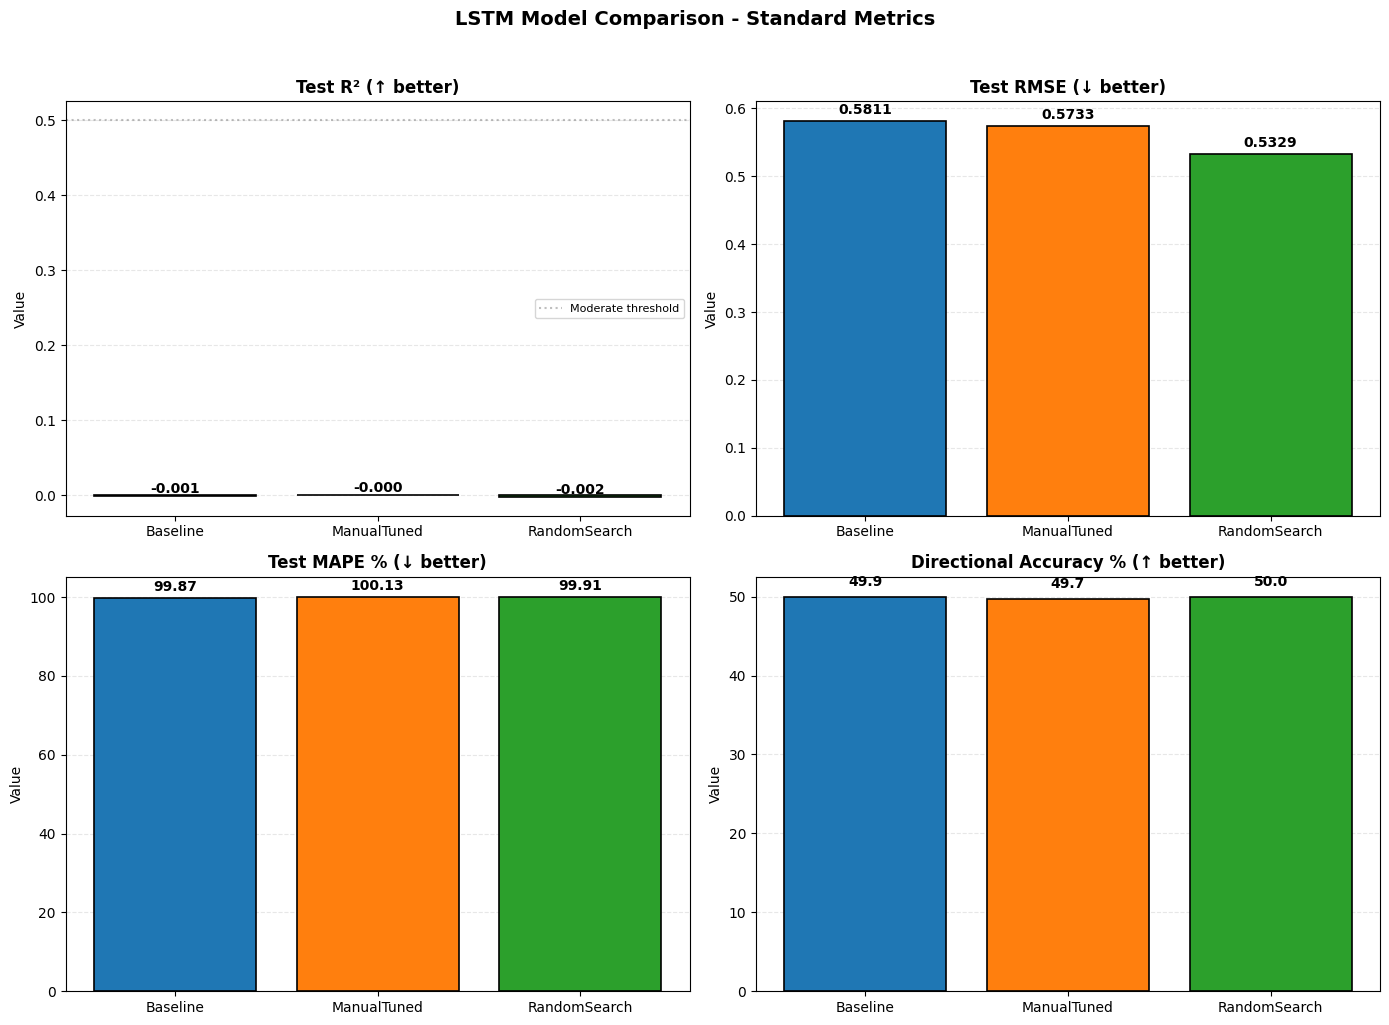

In [ ]:
# figure configuration
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# model labels and colors
model_labels = ["Baseline", "ManualTuned", "RandomSearch"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# metrics configuration
metrics = {
    "Test R2": {"title": "Test R² (↑ better)", "direction": "higher", "fmt": ".3f"},
    "Test RMSE": {"title": "Test RMSE (↓ better)", "direction": "lower", "fmt": ".4f"},
    "Test MAPE": {"title": "Test MAPE % (↓ better)", "direction": "lower", "fmt": ".2f"},
    "Test Dir Acc %": {"title": "Directional Accuracy % (↑ better)", "direction": "higher", "fmt": ".1f"}
}

# prepare values dictionary
values_dict = {
    "Test R2": performance_summary["Test R2"].values,
    "Test RMSE": performance_summary["Test RMSE"].values,
    "Test MAPE": performance_summary["Test MAPE"].values,
    "Test Dir Acc %": [test_acc_baseline, test_acc_manual, test_acc_random]
}

for i, (metric, config) in enumerate(metrics.items()):
    ax = axes[i]
    values = values_dict[metric]
    
    # Create bar chart
    bars = ax.bar(model_labels, values, color=colors, edgecolor='black', linewidth=1.2)
    
    # add value labels on top of bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        label_pos = height + (max(values) * 0.02) if config["direction"] == "higher" else height + (max(values) * 0.01)
        ax.text(bar.get_x() + bar.get_width()/2., label_pos, f'{value:{config["fmt"]}}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # formatting
    ax.set_title(config["title"], fontsize=12, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.set_axisbelow(True)
    
    # add horizontal reference line for "good" threshold
    if metric == "Test R2":
        ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Moderate threshold')
        ax.legend(fontsize=8, frameon=True)


plt.suptitle("LSTM Model Comparison - Standard Metrics", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# save figure
figure_path = FIGURE_ROOT / "04LSTM_Comparison_StandardMetrics.png"
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

## **Financial Metrics Radar Chart**

In [ ]:
fin_metrics = ['Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Total Return (%)']

# extract values
fin_values = {
    "Baseline": [
        fin_baseline['Sharpe Ratio'].values[0],
        fin_baseline['Sortino Ratio'].values[0],
        abs(fin_baseline['Max Drawdown'].values[0]),  # convert to positive for visualization
        fin_baseline['Total Return (%)'].values[0]
    ],
    "Optuna": [
        fin_optuna['Sharpe Ratio'].values[0],
        fin_optuna['Sortino Ratio'].values[0],
        abs(fin_optuna['Max Drawdown'].values[0]),
        fin_optuna['Total Return (%)'].values[0]
    ],
    "RandomSearch": [
        fin_random['Sharpe Ratio'].values[0],
        fin_random['Sortino Ratio'].values[0],
        abs(fin_random['Max Drawdown'].values[0]),
        fin_random['Total Return (%)'].values[0]
    ]
}

In [ ]:
# normalize metrics for radar chart
def normalize_metrics(values_dict, metrics, higher_is_better=None):
    
    if higher_is_better is None:
        # default: sharpe/Sortino/Return = higher better, Drawdown = lower better
        higher_is_better = [True, True, False, True]
    
    normalized = {}
    
    for idx, metric in enumerate(metrics):
        all_values = [values_dict[model][idx] for model in values_dict]
        min_val, max_val = min(all_values), max(all_values)
        range_val = max_val - min_val if max_val != min_val else 1
        
        for model in values_dict:
            
            if model not in normalized:
                normalized[model] = []
            
            val = values_dict[model][idx]
            
            # normalize
            if higher_is_better[idx]:
                norm_val = (val - min_val) / range_val
            
            else:
                norm_val = 1 - (val - min_val) / range_val  # invert for "lower is better"
            
            normalized[model].append(norm_val)
    
    return normalized

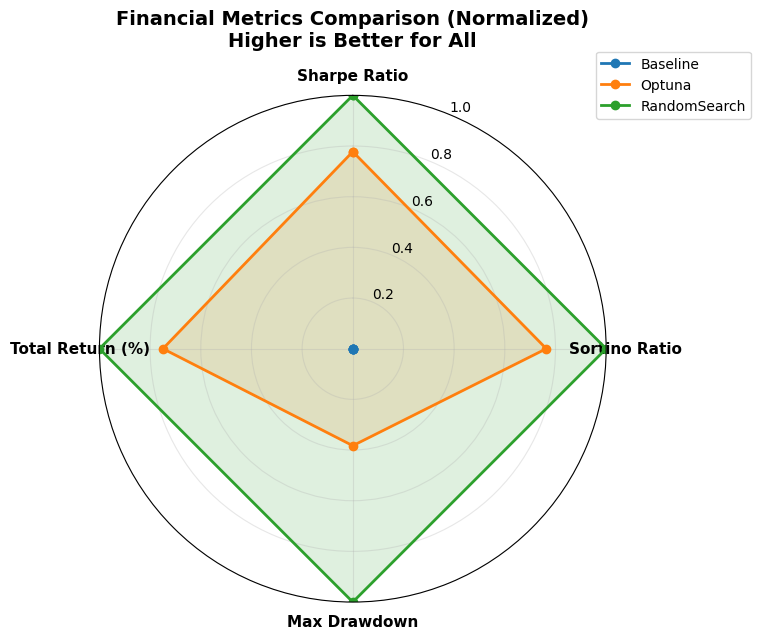

In [ ]:
normalized_financial = normalize_metrics(fin_values, fin_metrics)

# create radar chart
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw=dict(projection='polar'))

# angle for each metric
angles = np.linspace(0, 2 * np.pi, len(fin_metrics), endpoint=False).tolist()
angles += angles[:1]                        # close the loop

# plot each model
for model, color in zip(model_labels, colors):
    values = normalized_financial[model]
    values += values[:1]                    # close the loop
    
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=color, markersize=6)
    ax.fill(angles, values, alpha=0.15, color=color)

# formatting
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(fin_metrics, size=11, weight='bold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.title("Financial Metrics Comparison (Normalized)\nHigher is Better for All", fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout()

# save figure
figure_path = FIGURE_ROOT / "02LightGBM_Comparison_FinancialMetrics.png"
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()